<a href="https://colab.research.google.com/github/Mriano29/hotel_demand_forecasting_system/blob/main/data/base_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación del Dataset

Este proyecto prepara el dataset para desarrollar un sistema accesible de Gestión de Ingresos para hoteles medianos e independientes, que generalmente carecen de herramientas avanzadas para optimizar sus ingresos.

Se realizarán las siguientes etapas:
- Exploración inicial del dataset
- Limpieza de datos (nulos, duplicados, tipos, outliers)
- Feature engineering
- Análisis de correlación y selección de variables
- Evaluación de la calidad del dataset final

El objetivo final es obtener un dataset limpio y optimizado para:
- Predicción de cancelaciones
- Estimación de precios (ADR)
- Modelado de ocupación

##Indice

despues

##Exploración inicial

### Carga de datos

Se carga el dataset desde una fuente externa (GitHub) para garantizar reproducibilidad.

In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/Mriano29/hotel_demand_forecasting_system/refs/heads/main/data/hotel_booking.csv"

df = pd.read_csv(url)

###Visualización de las primeras filas

In [8]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


### Forma del dataset

In [9]:
df.shape

(119390, 36)

###Información general del dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

###Estadísticas básicas

In [11]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390,119390,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,4,NaN,NaN,NaN,3,926,81503,115889,119390,9000
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,Transient,NaN,NaN,NaN,Check-Out,2015-10-21,Robert Smith,Michael.C@gmail.com,422-804-6403,************3627
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,89613,NaN,NaN,NaN,75166,1461,48,6,1,28
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,101.831122,0.062518,0.571363,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,50.535790,0.245291,0.792798,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,-6.380000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,69.290000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,94.575000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,126.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN


###Nulos por columna

In [12]:
df.isnull().sum().sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4
arrival_date_year,0
lead_time,0
is_canceled,0
hotel,0
stays_in_weekend_nights,0
stays_in_week_nights,0


## Limpieza


###Eliminar duplicados

In [13]:
df.duplicated().sum()

df = df.drop_duplicates()

###Manejo de valores nulos

In [14]:
# Manejo de valores nulos
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

###Corrección de datos de fechas

In [15]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

###Conversión de variables categóricas

In [16]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].astype('category')

## Outliers


###Estado actual del dataset

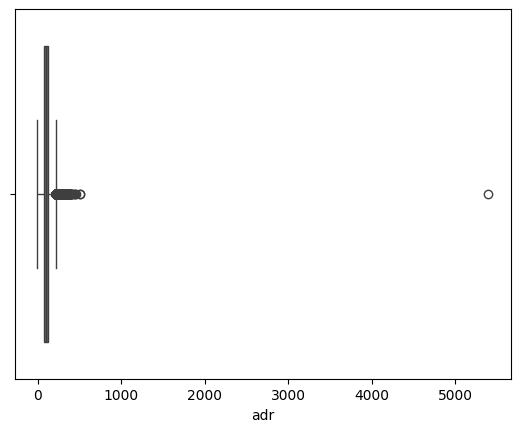

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['adr'])
plt.show()

###Tratamiento de outliers

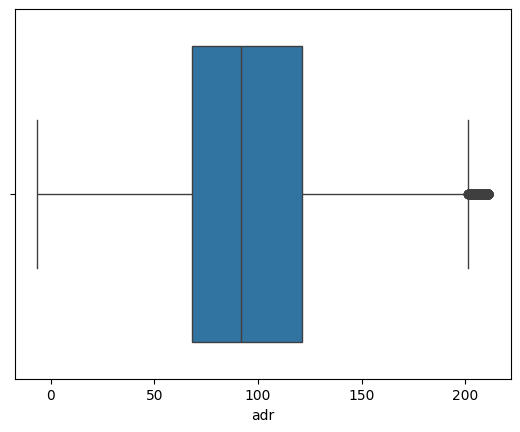

In [18]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['adr'] >= Q1 - 1.5*IQR) & (df['adr'] <= Q3 + 1.5*IQR)]
sns.boxplot(x=df['adr'])
plt.show()

## Analisis de correlacion

###Matríz de correlación

In [19]:
corr = df.select_dtypes(include=['int64','float64']).corr()

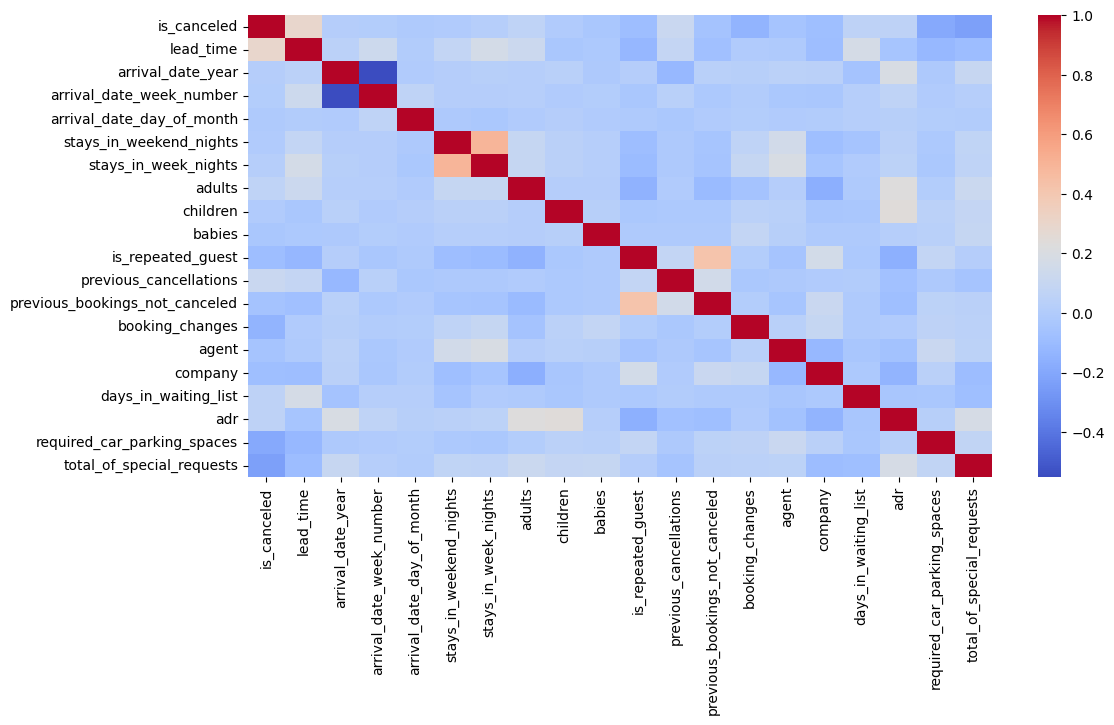

In [20]:
plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.show()

###Dendograma

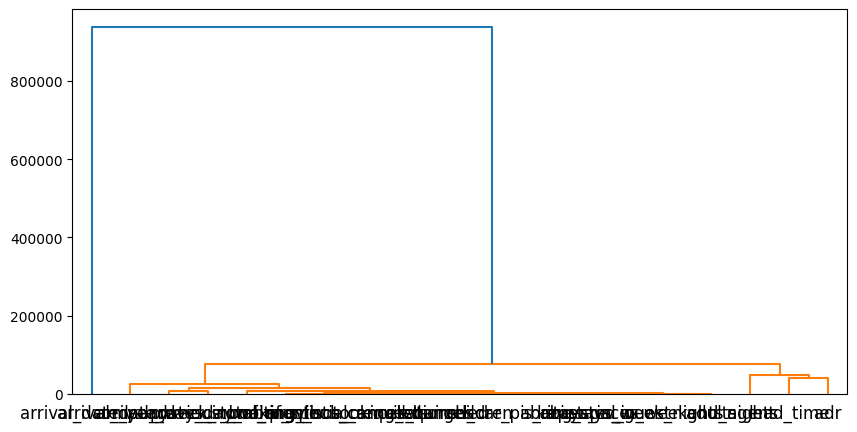

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage

numeric_df = df.select_dtypes(include=['int64','float64']).dropna()

linked = linkage(numeric_df.T, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked, labels=numeric_df.columns)
plt.show()

###Eliminado de columnas no relevantes

In [22]:
df = df.drop(columns=[
    'reservation_status',
    'assigned_room_type',
    'country'
])

## Balanceo del dataset

###Reservas canceladas

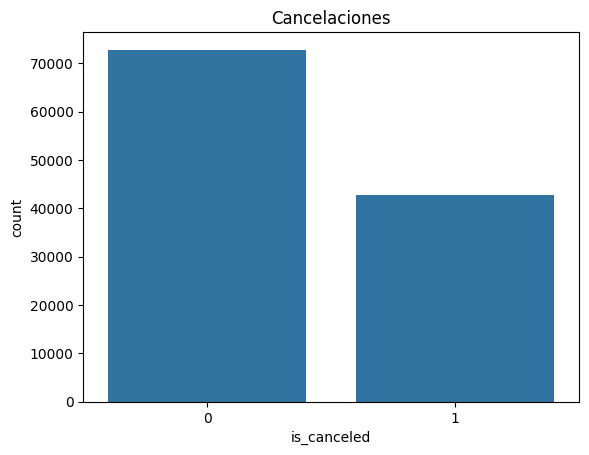

In [23]:
sns.countplot(x='is_canceled', data=df)
plt.title("Cancelaciones")
plt.show()

###Tipos de hotel

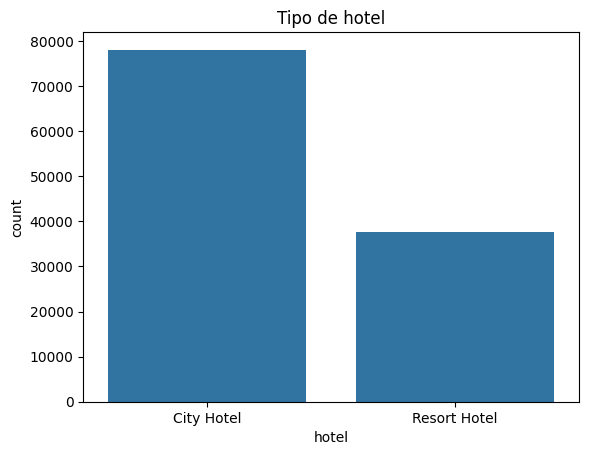

In [24]:
sns.countplot(x='hotel', data=df)
plt.title("Tipo de hotel")
plt.show()

### Tarifa media diaria

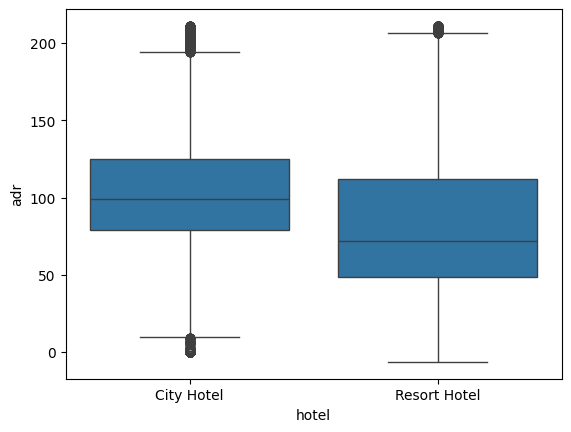

In [25]:
sns.boxplot(x='hotel', y='adr', data=df)
plt.show()

##Salud del dataset


###Valores faltantes

In [26]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

,0
children,0.00346
hotel,0.00000
is_canceled,0.00000
arrival_date_year,0.00000
lead_time,0.00000
arrival_date_week_number,0.00000
arrival_date_day_of_month,0.00000
stays_in_weekend_nights,0.00000
arrival_date_month,0.00000
stays_in_week_nights,0.00000


###Duplicados

In [27]:
df.duplicated().sum()

np.int64(0)

###Distribución de variables clave

In [28]:
#@title Reservas canceladas
df['is_canceled'].value_counts(normalize=True)

,proportion
is_canceled,
0,0.630137
1,0.369863


In [29]:
#@title Tarifa media diaria
df['adr'].describe()

,adr
count,115597.000000
mean,97.036643
std,40.614556
min,-6.380000
25%,68.000000
50%,92.000000
75%,121.370000
max,211.030000


###Outliers restantes

In [30]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['adr'] < Q1 - 1.5*IQR) | (df['adr'] > Q3 + 1.5*IQR)]

len(outliers) / len(df) * 100

0.8927567324411533

###Correlación final

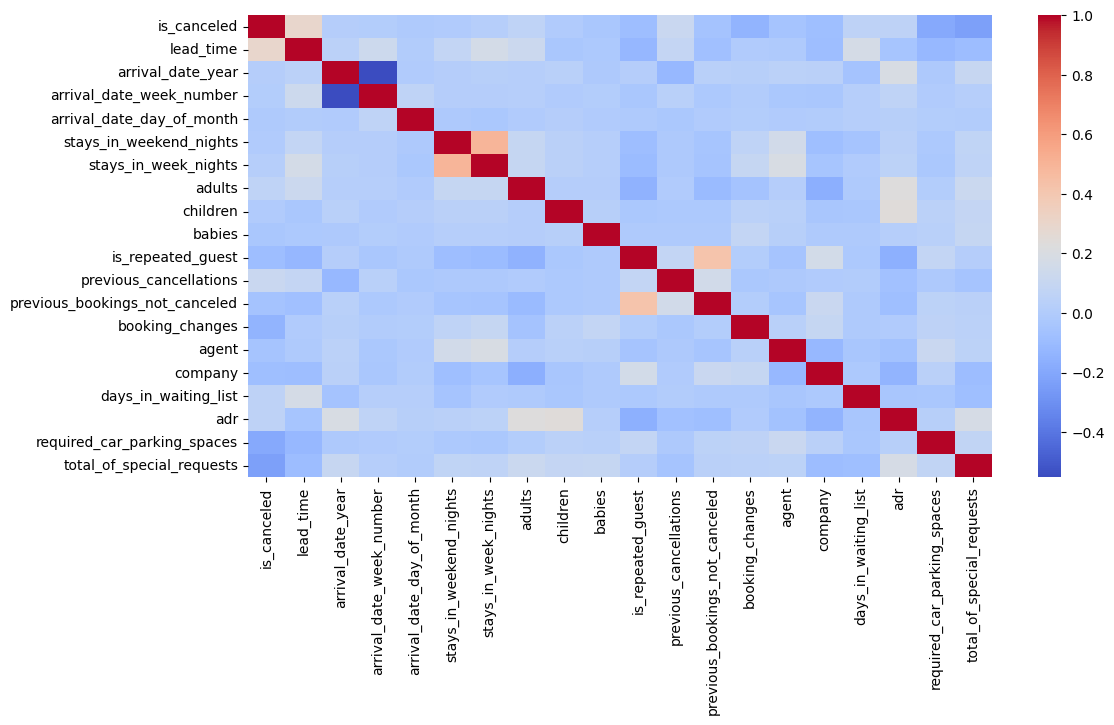

In [31]:
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

## Exportado del dataset limpio

In [32]:
df.to_csv("hotel_bookings_clean.csv", index=False)

##Conclusión

Tras la limpieza del dataset, se han eliminado duplicados, tratado valores nulos y corregido tipos de datos.
Se han detectado y gestionado outliers en variables numéricas como ADR.
El análisis de correlación no muestra redundancia crítica entre variables.
El dataset final presenta un alto nivel de calidad, siendo apto para análisis exploratorio avanzado y modelos predictivos.